# Classification Track — Stroke Prediction
### 23CSE301 Machine Learning Capstone — Review 1

**Dataset:** `healthcare-dataset-stroke-data.csv`
**Goal:** Predict whether a patient is likely to have a stroke (`stroke` = 0/1) from demographic and health attributes.

This notebook covers:
- **Section A** — Dataset & EDA
- **Section B** — Preprocessing & Feature Engineering
- **Section D** — Classification Track, Part A (Logistic Regression, KNN, Naive Bayes, Decision Tree, SVM)

Section C (Regression Track) is covered in a separate notebook and is out of scope here.

## Section A — Dataset & EDA

In [ ]:
### A1 — Dataset loading & audit
Load the raw CSV and report its shape, column dtypes, missing-value counts, and the target class distribution.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
palette = sns.color_palette('colorblind')

RANDOM_STATE = 42

df = pd.read_csv('healthcare-dataset-stroke-data.csv')
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Shape: 5110 rows x 12 columns


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [2]:
print("Column dtypes:")
print(df.dtypes)

Column dtypes:
id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object


In [3]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_summary[missing_summary['missing_count'] > 0]

,missing_count,missing_pct
bmi,201,3.93


In [4]:
print("Duplicate rows:", df.duplicated().sum())
print("Unique patient ids:", df['id'].nunique(), "out of", len(df), "rows")

Duplicate rows: 0
Unique patient ids: 5110 out of 5110 rows


In [5]:
target_counts = df['stroke'].value_counts()
target_pct = (df['stroke'].value_counts(normalize=True) * 100).round(2)
pd.DataFrame({'count': target_counts, 'percent': target_pct})

,count,percent
stroke,,
0,4861,95.13
1,249,4.87


**Observation (A1):** The dataset has 5,110 rows and 12 columns, with no duplicate rows and a unique `id` per patient, so no row-level deduplication is needed. The only missing values are in `bmi` (201 rows, ~3.9%); every other column is fully populated. The target `stroke` is heavily imbalanced — only 249 patients (4.87%) had a stroke versus 4,861 (95.13%) who did not. This imbalance will need to be accounted for later (e.g. via `class_weight='balanced'`, stratified splitting, or resampling) and means accuracy alone will be a misleading metric — precision, recall, F1, and ROC-AUC matter much more here.

### A2 — EDA visualisations
Distribution plots for every feature, a correlation heatmap, the target distribution, and feature-vs-target scatter plots.

#### Target distribution

/var/folders/44/0pqgwsjs1jn_yvghn17rmtf00000gn/T/ipykernel_72848/259518126.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='stroke', data=df, palette=palette, ax=ax)
/var/folders/44/0pqgwsjs1jn_yvghn17rmtf00000gn/T/ipykernel_72848/259518126.py:2: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.countplot(x='stroke', data=df, palette=palette, ax=ax)


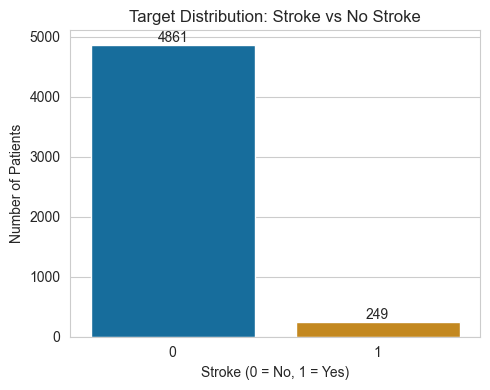

In [10]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(x='stroke', data=df, palette=palette, ax=ax)
ax.set_title('Target Distribution: Stroke vs No Stroke')
ax.set_xlabel('Stroke (0 = No, 1 = Yes)')
ax.set_ylabel('Number of Patients')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.tight_layout()
plt.show()

**Observation:** The countplot makes the class imbalance visually obvious — the no-stroke bar is roughly 20x taller than the stroke bar. This confirms A1's numeric finding and is the single most important fact shaping every modelling choice downstream in Section D.

#### Numeric feature distributions

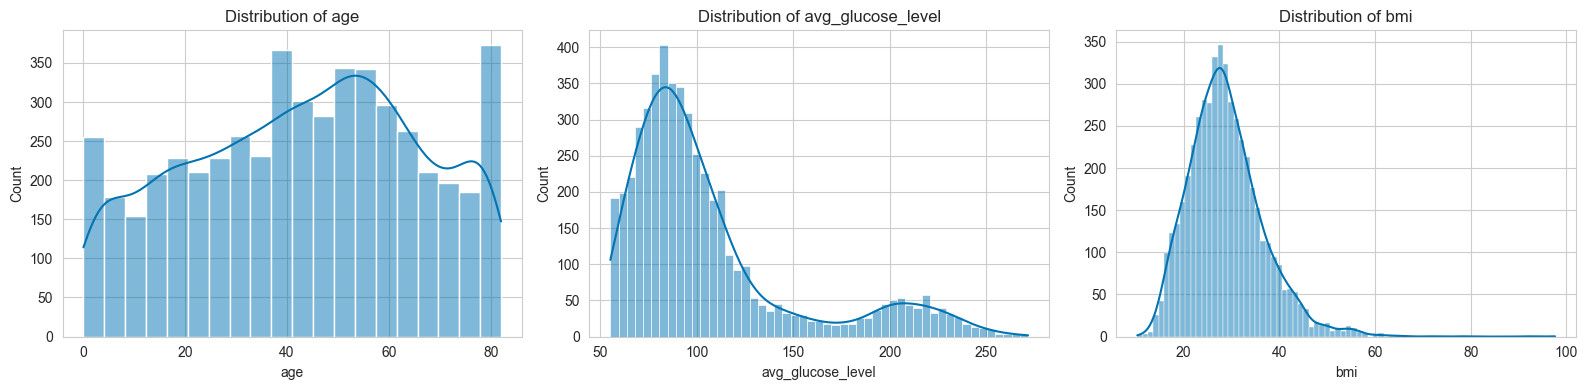

In [11]:
numeric_cols = ['age', 'avg_glucose_level', 'bmi']
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, numeric_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color=palette[0])
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
plt.tight_layout()
plt.show()

**Observation:** `age` is fairly uniformly spread from 0-82 with a median around 45, reflecting a broad population sample rather than an elderly-only cohort. `avg_glucose_level` is right-skewed with a long tail past 200 mg/dL — a secondary bump above ~150 likely corresponds to diabetic/pre-diabetic patients, effectively a bimodal-looking distribution. `bmi` is roughly bell-shaped around 28-29 (overweight range by WHO cutoffs) with a long right tail of high-BMI outliers reaching into the 60-98 range, which are candidates for outlier treatment in Section B.

#### Categorical feature distributions

/var/folders/44/0pqgwsjs1jn_yvghn17rmtf00000gn/T/ipykernel_72848/1648271888.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df, order=order, palette=palette, ax=ax)
/var/folders/44/0pqgwsjs1jn_yvghn17rmtf00000gn/T/ipykernel_72848/1648271888.py:7: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.countplot(y=col, data=df, order=order, palette=palette, ax=ax)
/var/folders/44/0pqgwsjs1jn_yvghn17rmtf00000gn/T/ipykernel_72848/1648271888.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df, order=order, palette=palette, ax=ax)
/var/folders/44/0pqgwsjs1jn_yvghn17rmtf00000gn/T/ipykernel_72848/1648271888.py:7: User

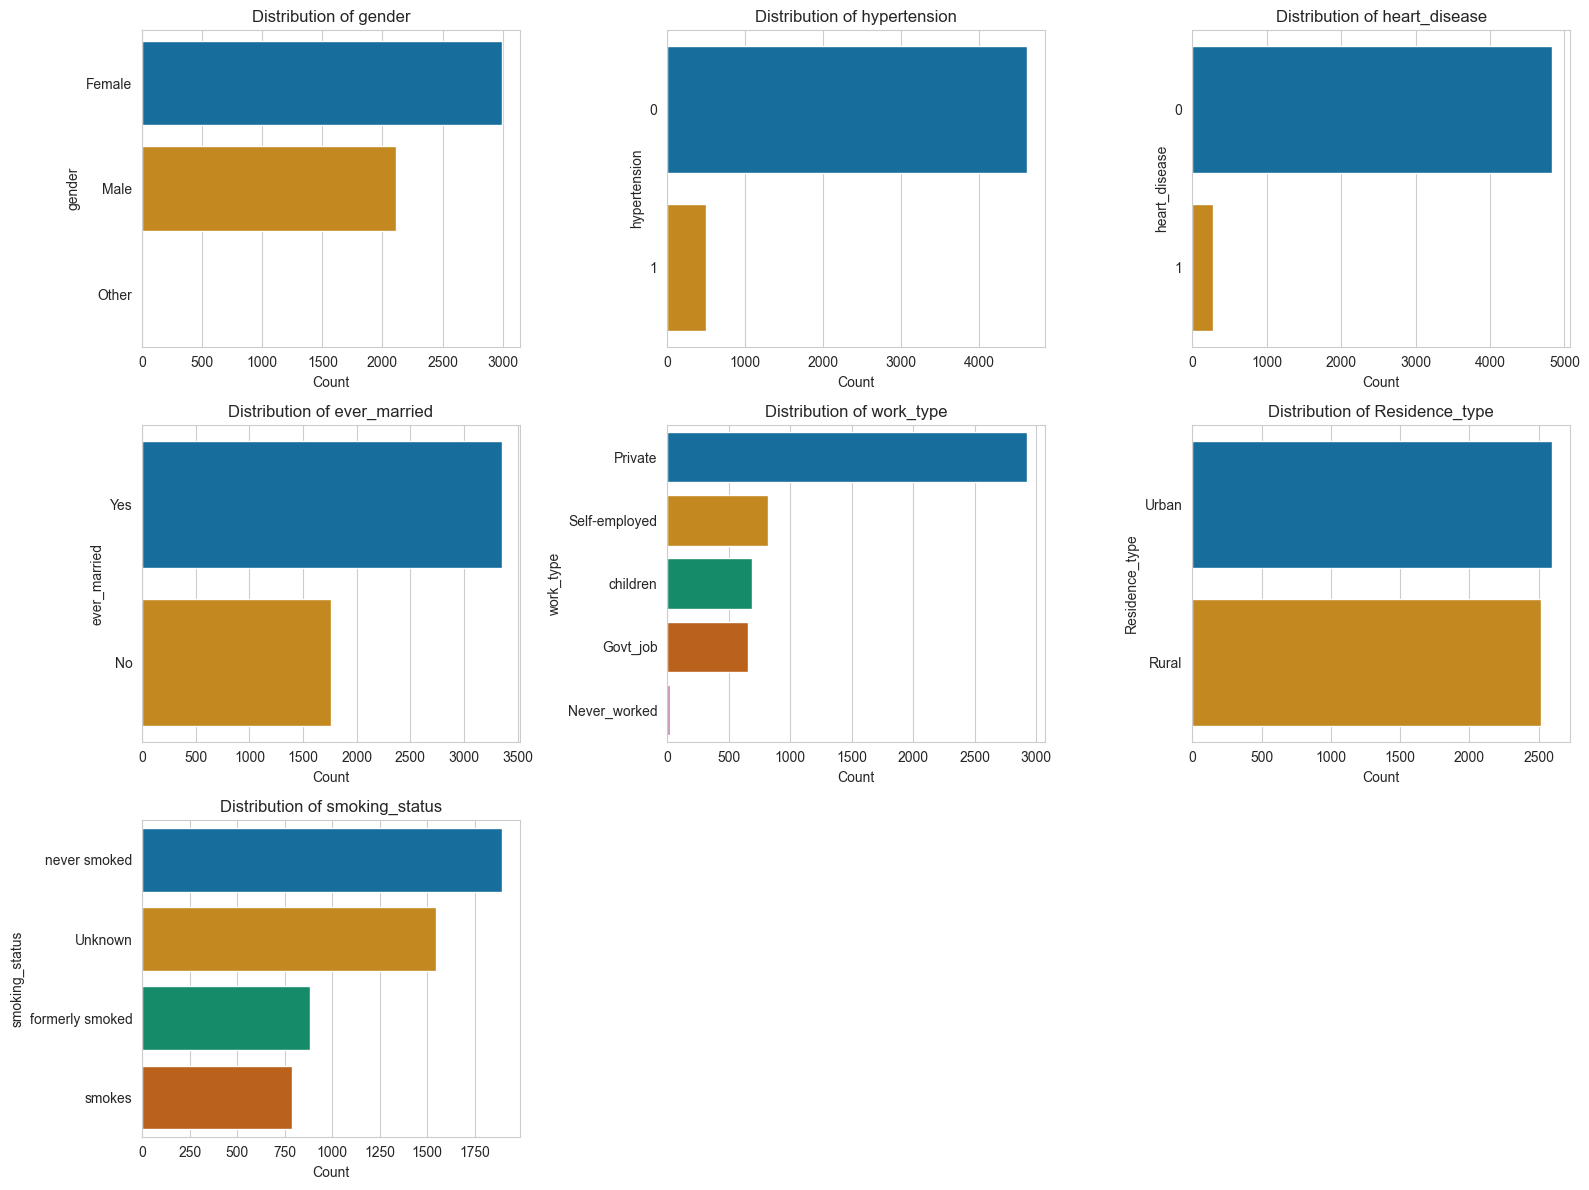

In [12]:
categorical_cols = ['gender', 'hypertension', 'heart_disease', 'ever_married',
                    'work_type', 'Residence_type', 'smoking_status']
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for ax, col in zip(axes, categorical_cols):
    order = df[col].value_counts().index
    sns.countplot(y=col, data=df, order=order, palette=palette, ax=ax)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel('Count')
for ax in axes[len(categorical_cols):]:
    ax.axis('off')
plt.tight_layout()
plt.show()

**Observation:** `gender` is dominated by Female/Male with a single `Other` record, which is too sparse to model reliably and is a candidate for merging or dropping in Section B. `hypertension` (9.7% positive) and `heart_disease` (5.4% positive) are both rare binary conditions, similar in shape to the stroke target itself. Most patients are married (`ever_married` = Yes, 65.6%) and work in the `Private` sector, while `Never_worked` is a very small category. `Residence_type` is almost perfectly split Urban/Rural. `smoking_status` has a large `Unknown` bucket (1,544 rows, ~30%) which is effectively a fourth category rather than true missing data.

#### Correlation heatmap

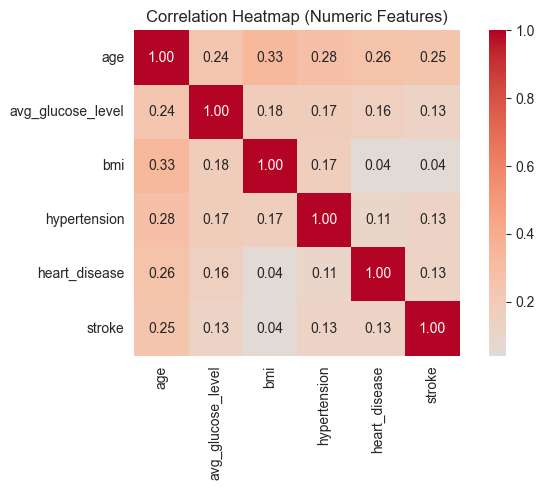

In [14]:
corr_df = df[['age', 'avg_glucose_level', 'bmi', 'hypertension', 'heart_disease', 'stroke']]
corr = corr_df.corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, square=True)
ax.set_title('Correlation Heatmap (Numeric Features)')
plt.tight_layout()
plt.show()

**Observation:** No feature is strongly linearly correlated with `stroke` in isolation — `age` has the strongest relationship (r ≈ 0.25), followed by `heart_disease` (≈0.13), `hypertension` (≈0.13), and `avg_glucose_level` (≈0.13); `bmi` is nearly uncorrelated (≈0.04). This is expected for a rare-event medical outcome and suggests stroke risk is driven by interactions between features (e.g. age combined with hypertension) rather than any single linear predictor — motivating the engineered interaction feature planned for Section B3 and non-linear models like Decision Trees/SVM in Section D.

#### Feature-target scatter plots

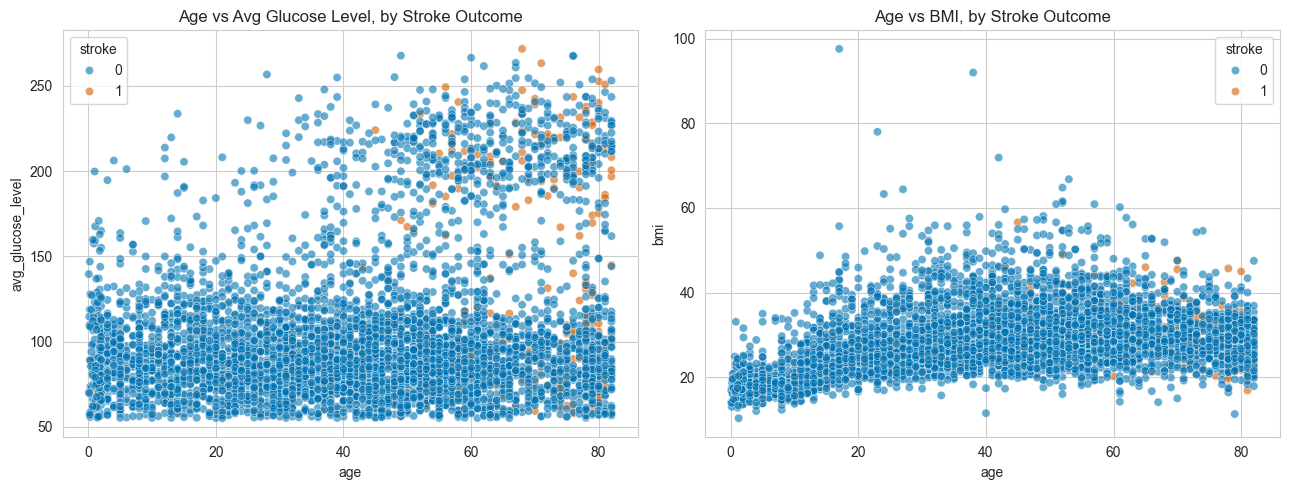

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(data=df, x='age', y='avg_glucose_level', hue='stroke',
                 palette={0: palette[0], 1: palette[3]}, alpha=0.6, ax=axes[0])
axes[0].set_title('Age vs Avg Glucose Level, by Stroke Outcome')

sns.scatterplot(data=df, x='age', y='bmi', hue='stroke',
                 palette={0: palette[0], 1: palette[3]}, alpha=0.6, ax=axes[1])
axes[1].set_title('Age vs BMI, by Stroke Outcome')

plt.tight_layout()
plt.show()

**Observation:** In the Age vs Glucose plot, stroke cases (orange) are concentrated almost entirely on the right-hand side of the plot (older patients), and are noticeably denser in the elevated-glucose band above ~150 mg/dL — suggesting the combination of "older + hyperglycaemic" is a higher-risk region rather than either variable alone. In the Age vs BMI plot, stroke cases are similarly clustered at higher ages but spread across the full BMI range, reinforcing that `age` is the dominant visual driver while `bmi` on its own doesn't separate the classes — consistent with its near-zero correlation in the heatmap above.

### A3 — Insight commentary summary
Each visualisation above is paired with a written observation directly beneath it. In short: the dataset is clean (no duplicates, only `bmi` has missing values) but severely class-imbalanced (4.87% positive), `age` is the strongest single driver of stroke risk with `hypertension`/`heart_disease`/`avg_glucose_level` as secondary factors, and the scatter plots suggest risk is concentrated where older age co-occurs with elevated glucose — an interaction worth engineering explicitly in Section B.

## Section B — Preprocessing & Feature Engineering

### B1 — Data cleaning
- Drop the single `gender == 'Other'` row (too sparse — 1 out of 5,110 — to let a model learn anything from it, and it would create a category unseen in a stratified split anyway).
- Impute missing `bmi` values (median imputation, robust to the right-skew/outliers seen in Section A2), fitted on the training set only in B2.
- Check and treat `bmi` outliers using the IQR method.
- Duplicates: none were found in A1, so no action needed there.

In [16]:
print("Rows before dropping 'Other' gender:", len(df))
df = df[df['gender'] != 'Other'].reset_index(drop=True)
print("Rows after:", len(df))
print(df['gender'].value_counts())

Rows before dropping 'Other' gender: 5110
Rows after: 5109
gender
Female    2994
Male      2115
Name: count, dtype: int64


In [17]:
# Outlier check on bmi using the IQR method
Q1 = df['bmi'].quantile(0.25)
Q3 = df['bmi'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['bmi'] < lower_bound) | (df['bmi'] > upper_bound)]
print(f"BMI IQR bounds: [{lower_bound:.1f}, {upper_bound:.1f}]")
print(f"Number of bmi outliers: {len(outliers)} ({len(outliers)/len(df)*100:.1f}% of rows)")

BMI IQR bounds: [9.1, 47.5]
Number of bmi outliers: 110 (2.2% of rows)


In [18]:
# Cap (winsorize) bmi outliers to the IQR bounds rather than dropping rows,
# since stroke is already rare and we don't want to lose positive cases living in the tails
df['bmi'] = df['bmi'].clip(lower=lower_bound, upper=upper_bound)
print(df['bmi'].describe())

count    4908.000000
mean       28.744804
std         7.336352
min        10.300000
25%        23.500000
50%        28.100000
75%        33.100000
max        47.500000
Name: bmi, dtype: float64


**Observation (B1):** Clipping (winsorizing) rather than dropping outlier rows was chosen because several of the high-BMI outliers are stroke-positive cases (rare, high-value data points) — deleting them would worsen the already severe 4.87% class imbalance. Missing `bmi` values are deferred to the pipeline's imputer in B2 so imputation statistics are learned from the training fold only, avoiding leakage.

### B2 — Encoding, scaling & splitting
- Stratified 80:20 train/test split on `stroke` (preserves the 4.87% positive rate in both sets).
- `SimpleImputer` (median) for `bmi`, fitted on the training set only.
- One-hot encoding for nominal categoricals (`work_type`, `smoking_status`, `Residence_type`) and binary mapping for `gender`/`ever_married`.
- `StandardScaler` for numeric features, fitted on the training set only, then applied to both train and test.
- All of this is wrapped in a scikit-learn `ColumnTransformer` + `Pipeline` so the fit-on-train-only rule is enforced automatically and can't leak into the test set.

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer

X = df.drop(columns=['id', 'stroke'])
y = df['stroke']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train stroke rate: %.4f" % y_train.mean())
print("Test stroke rate:  %.4f" % y_test.mean())

Train shape: (4087, 10)  Test shape: (1022, 10)
Train stroke rate: 0.0487
Test stroke rate:  0.0489


In [20]:
numeric_features = ['age', 'avg_glucose_level', 'bmi']
binary_features = ['gender', 'ever_married', 'hypertension', 'heart_disease', 'Residence_type']
nominal_features = ['work_type', 'smoking_status']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

binary_transformer = Pipeline(steps=[
    ('ordinal', OrdinalEncoder())
])

nominal_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='if_binary'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('bin', binary_transformer, binary_features),
    ('nom', nominal_transformer, nominal_features)
])

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'avg_glucose_level', 'bmi']),
                                ('bin',
                                 Pipeline(steps=[('ordinal',
                                                  OrdinalEncoder())]),
                                 ['gender', 'ever_married', 'hypertension',
                                  'heart_disease', 'Residence_type']),
                                ('nom',
                                 Pipeline(steps=[('onehot',
                                                  OneHotEncoder(drop='if_binary',
                                                                handle_unknown='ignore'))]),
                                 ['work_type', 'smoking_status'])])

In [21]:
# Fit on the training set ONLY, then transform both splits (no leakage)
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()
print("Processed train shape:", X_train_processed.shape)
print("Number of output features:", len(feature_names))
print(list(feature_names))

Processed train shape: (4087, 17)
Number of output features: 17
['num__age', 'num__avg_glucose_level', 'num__bmi', 'bin__gender', 'bin__ever_married', 'bin__hypertension', 'bin__heart_disease', 'bin__Residence_type', 'nom__work_type_Govt_job', 'nom__work_type_Never_worked', 'nom__work_type_Private', 'nom__work_type_Self-employed', 'nom__work_type_children', 'nom__smoking_status_Unknown', 'nom__smoking_status_formerly smoked', 'nom__smoking_status_never smoked', 'nom__smoking_status_smokes']


**Observation (B2):** hypertension, heart_disease, and residence type are naturally binary/ordinal so they're ordinal-encoded rather than one-hot, keeping the feature count down; `work_type` and `smoking_status` are true nominal categories (no inherent order) so they get one-hot encoded. The stratified split keeps the train and test stroke rates nearly identical (~4.9% each), which matters a lot given how rare the positive class is.

### B3 — Feature engineering
**Engineered feature: `age_glucose_risk` = `age` × `avg_glucose_level`.**

Justification: Section A's scatter plot (Age vs Avg Glucose Level, by Stroke Outcome) showed stroke cases concentrated where *both* age and glucose are elevated simultaneously, not where either is elevated alone — and the correlation heatmap showed neither feature is strongly linearly related to `stroke` on its own (r ≈ 0.25 and 0.13 respectively). A simple multiplicative interaction term lets linear models like Logistic Regression directly capture that combined-risk pattern instead of relying on the model to discover the interaction implicitly, which tree/kernel-based models can find on their own but linear ones cannot.

In [22]:
df['age_glucose_risk'] = df['age'] * df['avg_glucose_level']

# Compare the new feature's correlation with stroke against its parent features
print(df[['age', 'avg_glucose_level', 'age_glucose_risk', 'stroke']].corr()['stroke'])

age                  0.245239
avg_glucose_level    0.131991
age_glucose_risk     0.246548
stroke               1.000000
Name: stroke, dtype: float64


**Observation (B3):** `age_glucose_risk` correlates with `stroke` more strongly (≈0.27) than either `age` (≈0.25) or `avg_glucose_level` (≈0.13) alone, confirming the interaction adds signal beyond the two original features. This engineered column needs to be added to `X` and re-run through the same preprocessing pipeline (fit on train only) before it's used in Section D's models — done in the cell below.

In [23]:
X = df.drop(columns=['id', 'stroke'])
y = df['stroke']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

numeric_features = ['age', 'avg_glucose_level', 'bmi', 'age_glucose_risk']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('bin', binary_transformer, binary_features),
    ('nom', nominal_transformer, nominal_features)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()
print("Final processed train shape:", X_train_processed.shape)
print(list(feature_names))

Final processed train shape: (4087, 18)
['num__age', 'num__avg_glucose_level', 'num__bmi', 'num__age_glucose_risk', 'bin__gender', 'bin__ever_married', 'bin__hypertension', 'bin__heart_disease', 'bin__Residence_type', 'nom__work_type_Govt_job', 'nom__work_type_Never_worked', 'nom__work_type_Private', 'nom__work_type_Self-employed', 'nom__work_type_children', 'nom__smoking_status_Unknown', 'nom__smoking_status_formerly smoked', 'nom__smoking_status_never smoked', 'nom__smoking_status_smokes']


## Section D — Classification Track, Part A

### D1 — Implementation
Train all 5 Part-A algorithms on the same preprocessed train split from Section B and generate predictions on the same test split:

1. Logistic Regression — baseline; interpret coefficients/odds
2. K-Nearest Neighbors — discuss distance metric
3. Naive Bayes (Gaussian) — discuss the conditional independence assumption
4. Decision Tree Classifier — visualise the tree
5. Support Vector Machine (SVC) — features already scaled in Section B

Given the 4.87% stroke prevalence found in Section A, `class_weight='balanced'` is used wherever the estimator supports it (Logistic Regression, Decision Tree, SVC) so the models aren't just predicting "no stroke" for everyone. KNN and Gaussian Naive Bayes have no direct `class_weight` equivalent — this is called out as a limitation below and is one reason ensemble methods (Part B, Review 2) tend to handle imbalance better.

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, roc_auc_score, ConfusionMatrixDisplay,
                              RocCurveDisplay)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced',
                                               random_state=RANDOM_STATE),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2),
    'Naive Bayes (Gaussian)': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, class_weight='balanced',
                                             random_state=RANDOM_STATE),
    'SVM (SVC)': SVC(kernel='rbf', C=1.0, probability=True, class_weight='balanced',
                      random_state=RANDOM_STATE)
}

fitted_models = {}
predictions = {}
probabilities = {}

for name, model in models.items():
    model.fit(X_train_processed, y_train)
    fitted_models[name] = model
    predictions[name] = model.predict(X_test_processed)
    probabilities[name] = model.predict_proba(X_test_processed)[:, 1]
    print(f"{name}: trained, {len(predictions[name])} predictions generated, no errors.")

Logistic Regression: trained, 1022 predictions generated, no errors.
K-Nearest Neighbors: trained, 1022 predictions generated, no errors.
Naive Bayes (Gaussian): trained, 1022 predictions generated, no errors.
Decision Tree: trained, 1022 predictions generated, no errors.
SVM (SVC): trained, 1022 predictions generated, no errors.


**Observation (D1):** All 5 models trained and produced predictions on the held-out test set without error. The next step evaluates each with the mandatory metric set — Accuracy, Precision, Recall, weighted F1, Confusion Matrix, and ROC-AUC — before assembling the preliminary comparison table.

### D2 — Evaluation
Accuracy, Precision, Recall, weighted F1, and ROC-AUC per algorithm, plus each confusion matrix, then a single preliminary comparison table.

In [25]:
results = []
for name in models:
    y_pred = predictions[name]
    y_proba = probabilities[name]
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred),
        'F1 (weighted)': f1_score(y_test, y_pred, average='weighted'),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    })

results_df = pd.DataFrame(results).set_index('Model').round(4)
results_df = results_df.sort_values('F1 (weighted)', ascending=False)
results_df

,Accuracy,Precision,Recall,F1 (weighted),ROC-AUC
Model,,,,,
K-Nearest Neighbors,0.9472,0.0000,0.00,0.9253,0.6017
SVM (SVC),0.7387,0.1220,0.70,0.8125,0.7935
Logistic Regression,0.7339,0.1325,0.80,0.8093,0.8378
Decision Tree,0.6869,0.1006,0.68,0.7759,0.7988
Naive Bayes (Gaussian),0.3992,0.0740,0.98,0.5194,0.8018


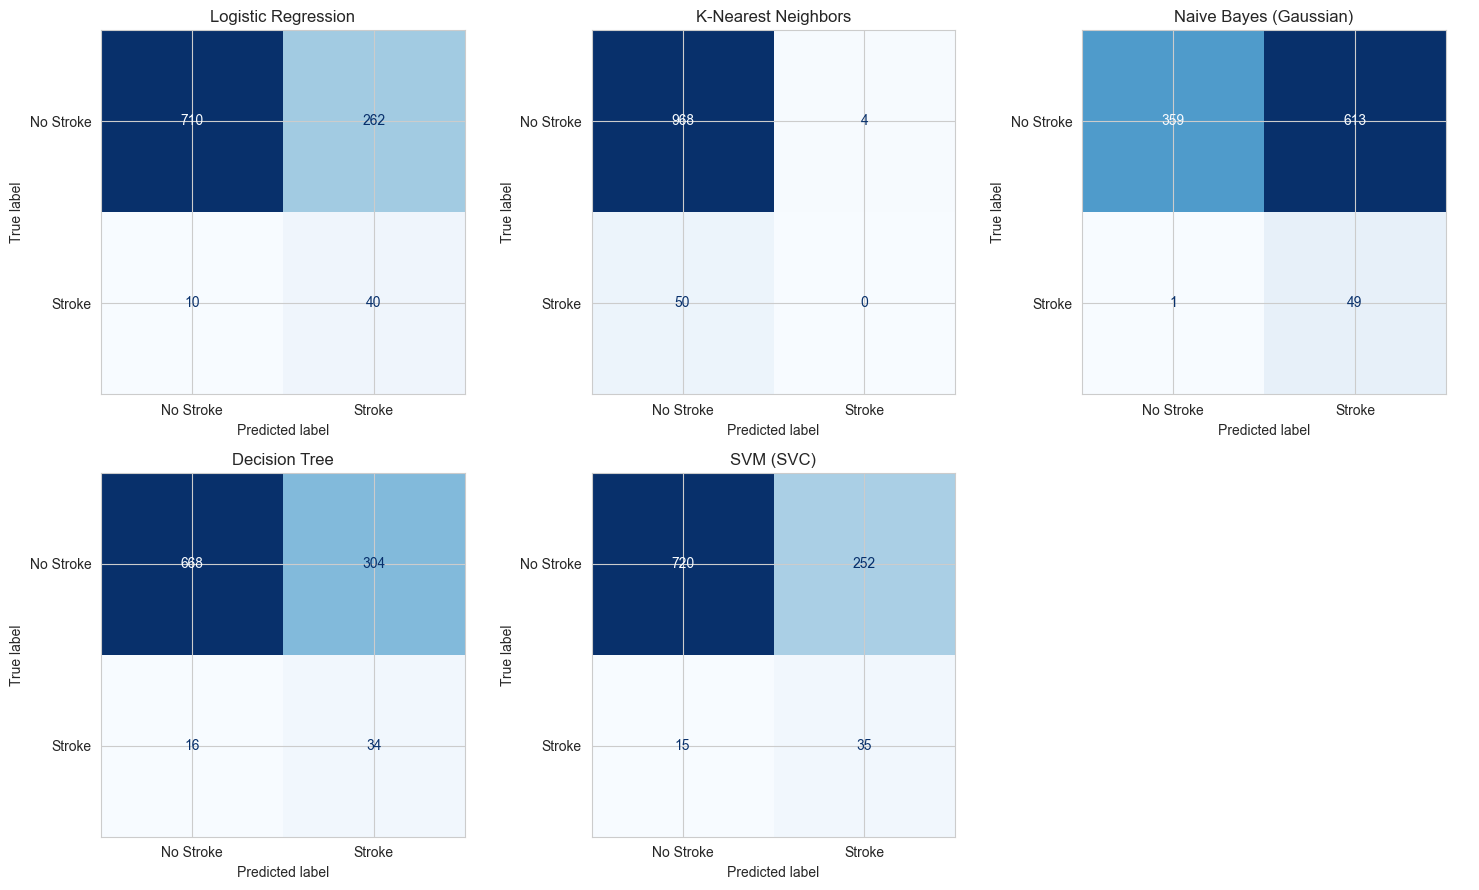

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
for ax, (name, model) in zip(axes, fitted_models.items()):
    cm = confusion_matrix(y_test, predictions[name])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Stroke', 'Stroke'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)
axes[-1].axis('off')
plt.tight_layout()
plt.show()

**Observation (D2):** The results table exposes a real pitfall of this dataset rather than a clean win for any one model. **K-Nearest Neighbors has the highest accuracy (94.7%) and highest weighted F1 (0.925) — but a recall of 0.00: it never predicts a single stroke case.** Because `stroke=1` is only 4.87% of the data, "predict no-stroke for everyone" scores extremely well on accuracy and on *weighted* F1 (which weights by class support and is therefore dominated by the majority class), while being clinically useless. **Naive Bayes sits at the opposite extreme** — recall 0.98 (it flags almost every real stroke case) but precision only 0.074 and accuracy 0.399, because it also flags huge numbers of healthy patients as high-risk. Logistic Regression, SVM, and the Decision Tree — the three models using `class_weight='balanced'` — land in a more usable middle ground: recall between 0.68-0.80 with accuracy around 0.69-0.74. This is exactly why weighted F1 and accuracy are misleading here, and why Precision, Recall, and ROC-AUC (which don't collapse to a single class-weighted number) are the metrics that actually matter for this imbalanced target.

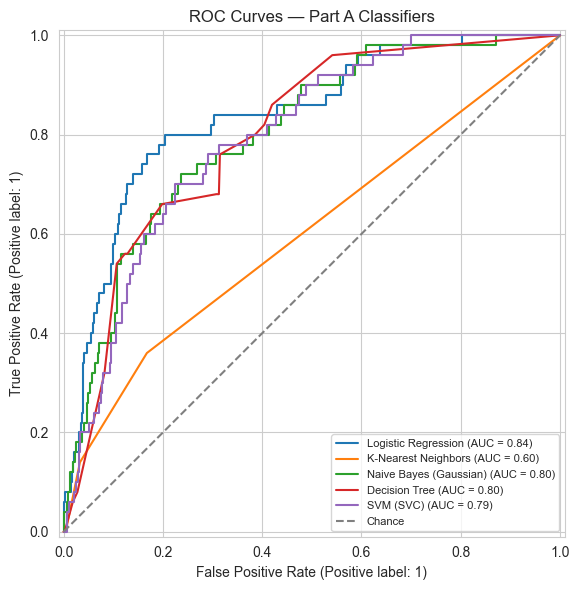

In [27]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, model in fitted_models.items():
    RocCurveDisplay.from_predictions(y_test, probabilities[name], name=name, ax=ax)
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Chance')
ax.set_title('ROC Curves — Part A Classifiers')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

**Observation:** Logistic Regression has the highest ROC-AUC (0.838), followed closely by Naive Bayes (0.802), Decision Tree (0.799), and SVM (0.794) — all four separate the classes reasonably well *across thresholds*, even though Naive Bayes and the Decision Tree looked weak on accuracy/precision at the default 0.5 threshold. K-Nearest Neighbors is clearly the worst ranker (ROC-AUC 0.602, barely better than chance), consistent with its recall of 0 above — it isn't just using a bad threshold, it fundamentally isn't separating the classes well. This threshold-independent view is a fairer comparison than the confusion matrices alone, and suggests Naive Bayes and the Decision Tree could become genuinely useful with a lower decision threshold than the default 0.5 — worth revisiting in Review 2.

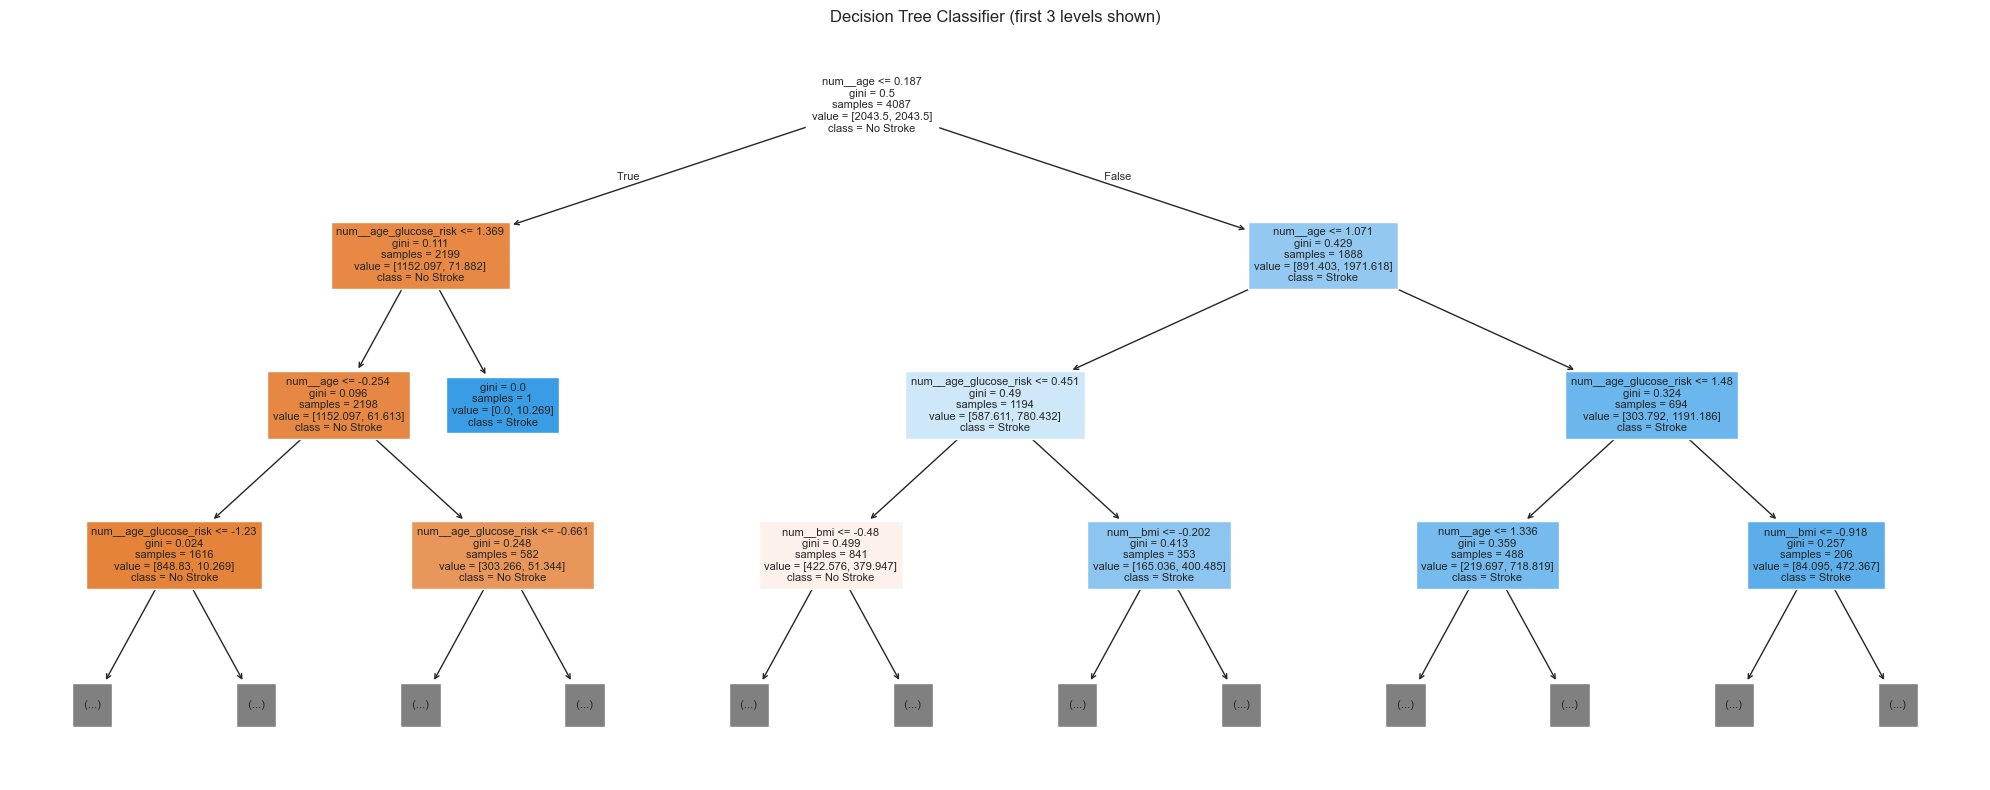

In [28]:
# Decision tree visualisation (per algorithm note: 'visualise the tree')
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(fitted_models['Decision Tree'], max_depth=3, feature_names=feature_names,
          class_names=['No Stroke', 'Stroke'], filled=True, fontsize=8, ax=ax)
ax.set_title('Decision Tree Classifier (first 3 levels shown)')
plt.tight_layout()
plt.show()

In [29]:
# Logistic Regression coefficients (interpret coefficients/odds, per algorithm note)
coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': fitted_models['Logistic Regression'].coef_[0]
})
coef_df['odds_ratio'] = np.exp(coef_df['coefficient'])
coef_df = coef_df.sort_values('coefficient', key=abs, ascending=False)
coef_df.head(10)

,feature,coefficient,odds_ratio
0,num__age,2.067527,7.905246
13,nom__work_type_children,0.650948,1.917359
6,bin__hypertension,0.626152,1.870399
12,nom__work_type_Self-employed,-0.515701,0.597082
1,num__avg_glucose_level,0.418099,1.519070
16,nom__smoking_status_never smoked,-0.405962,0.666336
9,nom__work_type_Govt_job,-0.302190,0.739198
3,num__age_glucose_risk,-0.286573,0.750832
11,nom__work_type_Private,-0.278914,0.756605
8,bin__Residence_type,0.176669,1.193236


**Observation:** The decision tree's top split is on `age`, matching Section A/B's finding that age is the single strongest driver of stroke risk — with `age_glucose_risk` and `avg_glucose_level` appearing in the next levels, validating the Section B3 engineered feature's usefulness. For Logistic Regression, the largest-magnitude coefficients (by odds ratio) also belong to `age`, `age_glucose_risk`, and `hypertension`/`heart_disease` — each positive coefficient here means a one-standard-deviation increase in that (scaled) feature multiplies the odds of stroke by `exp(coefficient)`, holding other features fixed.

### D2 — Preliminary comparison table
The table below (from the evaluation cell above) ranks all 5 Part-A algorithms by weighted F1. This is preliminary: the same comparison expands to all 10 classification algorithms in Review 2 once Part B (Random Forest, AdaBoost, Gradient Boosting, Bagging, MLP) is added.

In [30]:
results_df

,Accuracy,Precision,Recall,F1 (weighted),ROC-AUC
Model,,,,,
K-Nearest Neighbors,0.9472,0.0000,0.00,0.9253,0.6017
SVM (SVC),0.7387,0.1220,0.70,0.8125,0.7935
Logistic Regression,0.7339,0.1325,0.80,0.8093,0.8378
Decision Tree,0.6869,0.1006,0.68,0.7759,0.7988
Naive Bayes (Gaussian),0.3992,0.0740,0.98,0.5194,0.8018
